# Transaction Graph Analysis for AML Detection

This notebook demonstrates graph-based money laundering detection using the `aml-analytics` toolkit.

 We build a transaction network from synthetic data and apply three detection methods:
 - **Structuring detection** — accounts breaking up amounts below the $10,000 CTR threshold
 - **Layering detection** — funds moving through chains of accounts to obscure origin
 - **Centrality scoring** — identifying high-risk funnel accounts in the network

 All analysis uses synthetic data generated by `aml.synthetic` — no real transaction data.

In [47]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [48]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from aml.synthetic import generate_transactions, get_summary
from aml.graph import build_network, detect_structuring, detect_layering, centrality_score, get_network_summary

print("All modules loaded successfully")

All modules loaded successfully


In [49]:
## 1. Generate synthetic transaction data

In [50]:
df = generate_transactions(n=1000, seed=42)
get_summary(df)

Total transactions : 1,001
Unique senders     : 50
Unique receivers   : 50
Date range         : 2023-01-01 → 2023-12-30
Amount range       : $13.99 → $584,842.14

Label breakdown:
label
normal         869
layering        52
structuring     50
smurfing        30


In [51]:
df.head(10)

,transaction_id,sender_id,receiver_id,amount,timestamp,channel,country,label
0,TXN0000748,ACC00167403,ACC09577630,582.26,2023-01-01 16:45:27,digital_wallet,RU,normal
1,TXN0000916,ACC28437201,ACC51982661,8682.37,2023-01-01 22:14:37,cash,US,structuring
2,TXN0000855,ACC40250165,ACC38926395,15225.95,2023-01-02 14:26:12,ACH,US,normal
3,TXN0000848,ACC89880739,ACC93008687,71894.15,2023-01-02 19:55:58,check,MX,normal
4,TXN0000377,ACC42572396,ACC69111526,6690.75,2023-01-04 04:13:08,wire,RU,normal
5,TXN0000144,ACC88308904,ACC28437201,2384.99,2023-01-04 15:35:25,check,MX,normal
6,TXN0000517,ACC93008687,ACC89880739,3832.90,2023-01-04 16:04:55,ACH,US,normal
7,TXN0000597,ACC93008687,ACC04447690,1206.15,2023-01-04 17:19:26,check,US,normal
8,TXN0000884,ACC42149696,ACC25808631,9703.15,2023-01-04 19:33:09,cash,US,structuring
9,TXN0000568,ACC57129557,ACC63322966,398.56,2023-01-05 02:18:44,wire,MX,normal


In [52]:
## 2. Build the transaction network

In [53]:
G = build_network(df)
get_network_summary(G)

Nodes (accounts)   : 50
Edges (transactions): 831
Is directed        : True
Avg degree         : 33.24
Max degree node    : ACC88827188


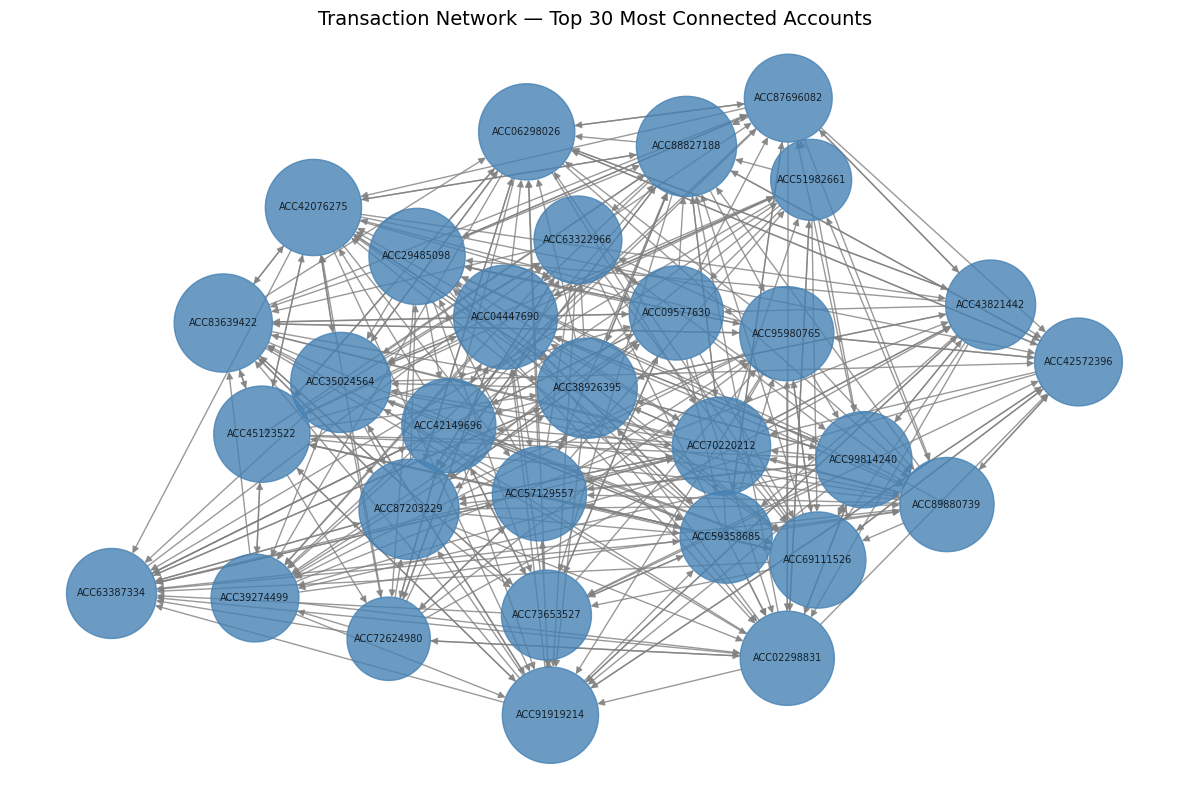

Network graph saved


In [54]:
# Visualize a sample subgraph — top 30 most connected nodes
top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:30]
top_node_ids = [n[0] for n in top_nodes]
subgraph = G.subgraph(top_node_ids)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subgraph, seed=42)
degrees = dict(subgraph.degree())
node_sizes = [degrees[n] * 200 for n in subgraph.nodes()]

nx.draw_networkx(
    subgraph,
    pos=pos,
    node_size=node_sizes,
    node_color="steelblue",
    edge_color="gray",
    alpha=0.8,
    with_labels=True,
    font_size=7,
    arrows=True,
)
plt.title("Transaction Network — Top 30 Most Connected Accounts", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig("network_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Network graph saved")

## 3. Detect structuring
Accounts making multiple cash transactions just below the $10,000 CTR threshold within a 48-hour window.

In [55]:
structuring_alerts = detect_structuring(G, threshold=9_000)
print(f"Structuring alerts detected: {len(structuring_alerts)}")

if structuring_alerts:
    structuring_df = pd.DataFrame(structuring_alerts)
    print(structuring_df[["sender_id", "transaction_count", "total_amount", "time_window_hours"]].head(10))

Structuring alerts detected: 31
     sender_id  transaction_count  total_amount  time_window_hours
0  ACC51982661                  2       8236.41              36.41
1  ACC38926395                  2       7806.01              27.52
2  ACC89880739                  2       5614.86              41.64
3  ACC93008687                  2       5039.05               1.24
4  ACC69111526                  2       4990.85              31.80
5  ACC04447690                  2       1257.91              16.70
6  ACC25808631                  2       4235.34               5.24
7  ACC57129557                  2       6212.56               8.21
8  ACC39274499                  2       2009.80              34.89
9  ACC62370499                  3       9447.63              45.99


## 4. Detect layering chains
 Funds moving through 3+ accounts in sequence to obscure the origin of funds.

In [56]:
layering_chains = detect_layering(G, min_hops=3, max_hops=5)
print(f"Layering chains detected: {len(layering_chains)}")

if layering_chains:
    layering_df = pd.DataFrame(layering_chains)
    print(layering_df[["chain_length", "total_amount", "start_node", "end_node"]].head(10))

Layering chains detected: 4
   chain_length  total_amount   start_node     end_node
0             3      23000.41  ACC40250165  ACC28437201
1             3       8991.50  ACC42572396  ACC09577630
2             3      11866.28  ACC42572396  ACC62370499
3             3      16242.65  ACC04447690  ACC21954781


## 5. Centrality scoring — identifying funnel accounts
High betweenness centrality accounts sit at the center of many transaction flows, consistent with funnel accounts used in layering schemes.

In [57]:
scores = centrality_score(G)
print("Top 10 highest risk accounts:")
print(scores.head(10))

Top 10 highest risk accounts:
       node_id  degree_centrality  betweenness_centrality  \
0  ACC88827188           0.857143                0.023177   
1  ACC91919214           0.816327                0.019103   
2  ACC06298026           0.795918                0.021360   
3  ACC04447690           0.816327                0.019827   
4  ACC38926395           0.816327                0.018549   
5  ACC63387334           0.775510                0.020850   
6  ACC42076275           0.795918                0.020105   
7  ACC63322966           0.755102                0.014318   
8  ACC99814240           0.775510                0.018286   
9  ACC57129557           0.755102                0.016414   

   in_degree_centrality  risk_score  
0              0.469388    0.362609  
1              0.510204    0.356490  
2              0.448980    0.339251  
3              0.408163    0.336444  
4              0.408163    0.335805  
5              0.448980    0.332874  
6              0.408163    0.330

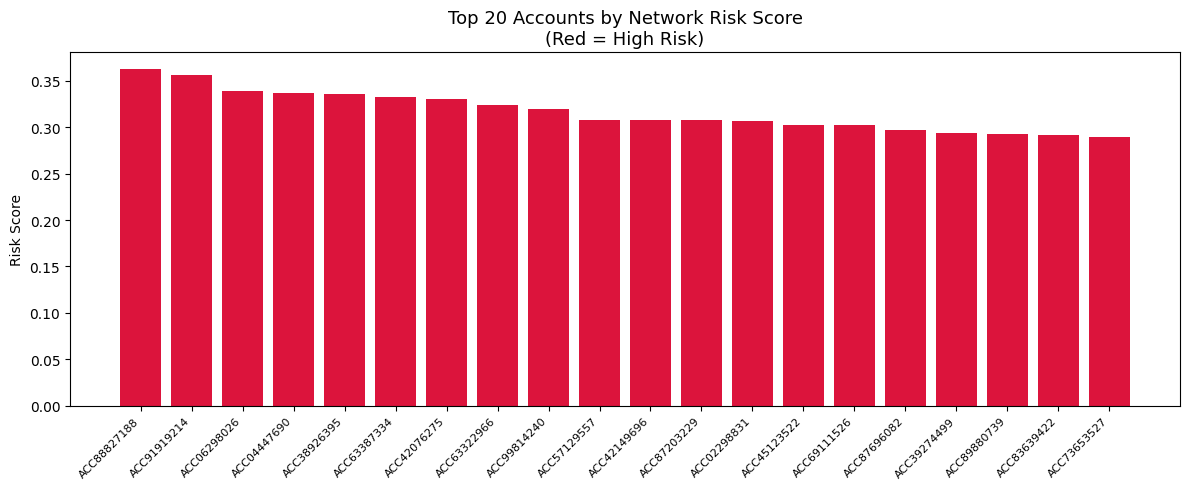

In [58]:
# Visualize top 20 accounts by risk score
top20 = scores.head(20)

plt.figure(figsize=(12, 5))
colors = ["crimson" if s > 0.1 else "steelblue" for s in top20["risk_score"]]
bars = plt.bar(range(len(top20)), top20["risk_score"], color=colors)
plt.xticks(range(len(top20)), top20["node_id"], rotation=45, ha="right", fontsize=8)
plt.ylabel("Risk Score")
plt.title("Top 20 Accounts by Network Risk Score\n(Red = High Risk)", fontsize=13)
plt.tight_layout()
plt.savefig("risk_scores.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

 | Detection Method | Alerts Found |
 |---|---|
 | Structuring | See output above |
 | Layering chains | See output above |
 | High centrality accounts | Top 10 shown above |

 This notebook demonstrates how graph-based analytics can surface AML patterns that rule-based systems miss. The combination of network topology (centrality), path analysis (layering), and threshold monitoring (structuring) provides a multi-dimensional view of account risk.

 All code is available in the `aml-analytics` toolkit: [github.com/Bhavesh0205/aml-analytics](https://github.com/Bhavesh0205/aml-analytics)